<a href="https://colab.research.google.com/github/luisnguitjab/2026/blob/main/TP2_POAD_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Con el objetivo de trazar **gráfico**s eficientes para la **representación de datos:**

1º **Importar** 2 o más fuentes sobre una misma temática, organizar y concatenar en al menos 1 DataFrame. Puede ser DER, un diagrama de clases u otro formato que permita ver columnas y tipos de datos que contienen.

2º A partir del DataFrame, programar 1 grafico o 1 widget en **Matplotlib**.

3º Programar 1 gráfico en **Seaborn**.

4º Programar 1 gráfico interactivo en express o graph_objects de **Plotly**.


**Bibliografía**

Nelli, Fabio. Python Data Analytics: With Pandas, NumPy, and Matplotlib. Apress. 3° edición.

Milovanović, Igor; Foures, Dimitry & Vettigli, Giuseppe. Python Data Visualization
Cookbook. Packt Publishing. 2° edición.

VanderPlas, Jake. Python Data Science Handbook. O’Reilly. 1° edición.


Sea un escenario de **Ventas Tecnológicas** con **datos simulado**s mediante cadenas de texto.
Se define la estructura de los datos a consolidar:

**Columna	    Tipo de dato(Pandas)	Descripción**

Fecha	      datetime64[ns]	      fecha del registro de ventas.

Producto	  object (string)	      categoría del producto vendido.

Region	    object (string)	      zona geográfica de la venta.

Ventas	    int64	                unidades vendidas.

Ingresos	  float64	              valor en $.


A continuación, el código para crear y concatenar los DataFrames:

In [5]:
import pandas as pd
import numpy as np

# Configurar semilla para que los datos aleatorios sean siempre los mismos al ejecutar
np.random.seed(42)

# Definir el rango temporal (12 meses del año 2023) y el catálogo de productos
fechas = pd.date_range(start='2023-01-01', end='2023-12-01', freq='MS')
productos = ['Smartphone', 'Laptop', 'Tablet', 'Smartwatch']

# Función para simular una fuente de datos (archivos/bases de datos distintas)
def simular_fuente(region, volumen_base):
    registros = []
    precios_base = {'Smartphone': 500, 'Laptop': 1200, 'Tablet': 300, 'Smartwatch': 200}

    for fecha in fechas:
        for producto in productos:
            # Generar ventas con una distribución normal para darle realismo
            ventas = int(np.random.normal(loc=volumen_base, scale=25))
            ventas = max(10, ventas) # Asegurar que no haya ventas negativas

            # Calcular ingresos con una ligera fluctuación de precios (descuentos, inflación, etc.)
            ingresos = ventas * precios_base[producto] * np.random.uniform(0.9, 1.1)

            registros.append([fecha, producto, region, ventas, round(ingresos, 2)])

    return pd.DataFrame(registros, columns=['Fecha', 'Producto', 'Region', 'Ventas', 'Ingresos'])

# Fuente 1: Datos de la Región Norte (simulamos que venden un poco más en promedio)
df_norte = simular_fuente('Norte', volumen_base=150)

# Fuente 2: Datos de la Región Sur
df_sur = simular_fuente('Sur', volumen_base=110)

# Organizar y concatenar las fuentes en 1 solo DataFrame
df_consolidado = pd.concat([df_norte, df_sur], ignore_index=True)

# Mostrar la cantidad de registros y una muestra aleatoria
print(f"Total de registros consolidados: {len(df_consolidado)}")
display(df_consolidado.sample(5))

Total de registros consolidados: 96


,Fecha,Producto,Region,Ventas,Ingresos
12,2023-04-01,Smartphone,Norte,186,87413.93
42,2023-11-01,Tablet,Norte,159,50187.89
44,2023-12-01,Smartphone,Norte,149,74838.72
35,2023-09-01,Smartwatch,Norte,173,31652.39
56,2023-03-01,Smartphone,Sur,92,43497.00


In [ ]:
import pandas as pd
import io

# Fuente 1: Ventas de la Región Norte
csv_norte = """Fecha,Producto,Region,Ventas,Ingresos
2023-01-01,Smartphone,Norte,150,75000.0
2023-01-01,Laptop,Norte,40,48000.0
2023-02-01,Smartphone,Norte,180,90000.0
2023-02-01,Laptop,Norte,55,66000.0
2023-03-01,Smartphone,Norte,210,105000.0
2023-03-01,Laptop,Norte,70,84000.0"""

# Fuente 2: Ventas de la Región Sur
csv_sur = """Fecha,Producto,Region,Ventas,Ingresos
2023-01-01,Smartphone,Sur,120,60000.0
2023-01-01,Laptop,Sur,30,36000.0
2023-02-01,Smartphone,Sur,140,70000.0
2023-02-01,Laptop,Sur,45,54000.0
2023-03-01,Smartphone,Sur,160,80000.0
2023-03-01,Laptop,Sur,60,72000.0"""

# Creación de DataFrames
df_norte = pd.read_csv(io.StringIO(csv_norte), parse_dates=['Fecha'])
df_sur = pd.read_csv(io.StringIO(csv_sur), parse_dates=['Fecha'])

# Concatenación
df_consolidado = pd.concat([df_norte, df_sur], ignore_index=True)

# Verificación de datos
display(df_consolidado.head())

,Fecha,Producto,Region,Ventas,Ingresos
0,2023-01-01,Smartphone,Norte,150,75000.0
1,2023-01-01,Laptop,Norte,40,48000.0
2,2023-02-01,Smartphone,Norte,180,90000.0
3,2023-02-01,Laptop,Norte,55,66000.0
4,2023-03-01,Smartphone,Norte,210,105000.0


2. **Gráfico en Matplotlib**: muestra la evolución de los ingresos totales a lo largo del tiempo.

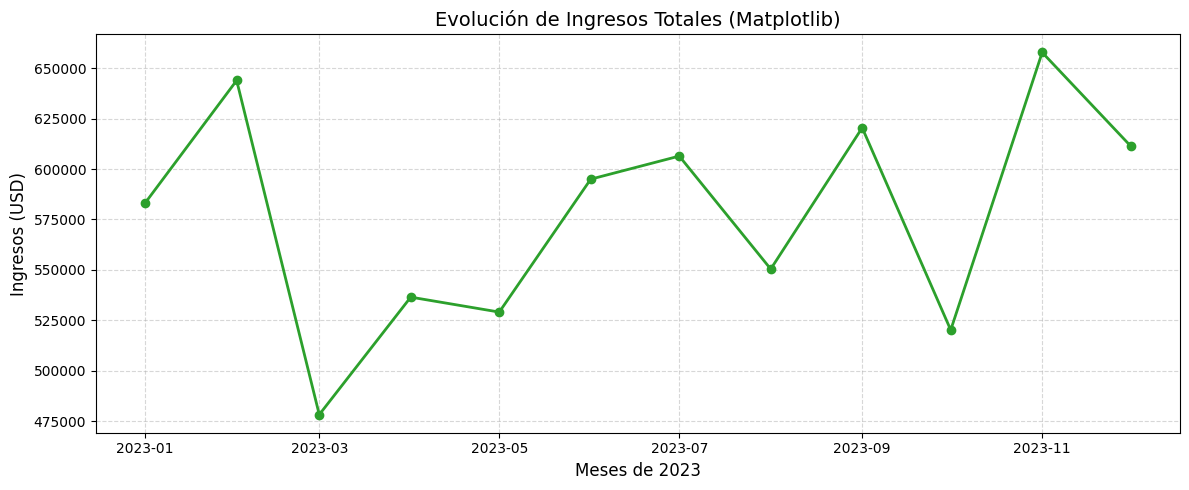

In [6]:
import matplotlib.pyplot as plt

# Agrupar ingresos por fecha en ambas regiones
ingresos_temporales = df_consolidado.groupby('Fecha')['Ingresos'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ingresos_temporales.index, ingresos_temporales.values, marker='o', linestyle='-', color='#2ca02c', linewidth=2)

ax.set_title('Evolución de Ingresos Totales (Matplotlib)', fontsize=14)
ax.set_xlabel('Meses de 2023', fontsize=12)
ax.set_ylabel('Ingresos (USD)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

3. **Gráfico en Seaborn:** (basado en matplotlib) gráfico de barras agrupadas para comparar las ventas por producto y región.

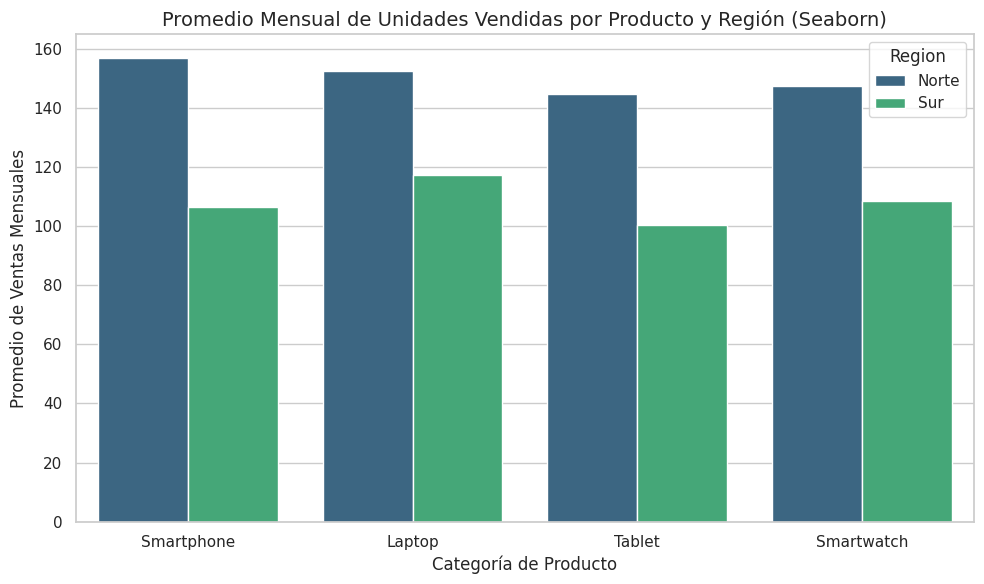

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Seaborn suma y promedia automáticamente si hay muchos registros del mismo producto/región
sns.barplot(data=df_consolidado, x='Producto', y='Ventas', hue='Region', palette='viridis', errorbar=None)

plt.title('Promedio Mensual de Unidades Vendidas por Producto y Región (Seaborn)', fontsize=14)
plt.xlabel('Categoría de Producto')
plt.ylabel('Promedio de Ventas Mensuales')

plt.tight_layout()
plt.show()

4. **Gráfico Interactivo en Plotly Express**: gráfico de dispersión (scatter) donde el tamaño de la burbuja representa los ingresos, ideal para explorar datos interactuando con el cursor.

In [8]:
import plotly.express as px
import plotly.io as pio

# Renderizador para Google Colab
pio.renderers.default = 'colab'

# Gráfico de dispersión interactivo
fig = px.scatter(df_consolidado,
                 x="Ventas",
                 y="Ingresos",
                 color="Region",
                 size="Ingresos",
                 hover_name="Producto",
                 hover_data={"Fecha": "|%B %Y", "Region": False}, # Formatea la fecha y oculta la región duplicada
                 title="Dispersión: Ventas vs Ingresos a lo largo del año (Plotly Express)",
                 labels={"Ventas": "Unidades Vendidas", "Ingresos": "Ingresos (USD)"},
                 template="plotly_dark") # Usamos un tema oscuro para resaltar los colores

fig.show()